<a href="https://colab.research.google.com/github/DyreDev/Campo-Rugby/blob/main/Analise_rugby.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **JOGOS INTERNACIONAIS DAS SELEÇÕES DESDE 1871 A 2023**

Kaio Wellington Farias Da Costa
RA:10724113141

Escolhir fazer uma análise de dados relacionados ao conjunto de dados dos mundiais de Rugby desde 1871 a 2023.

link: https://www.kaggle.com/datasets/lylebegbie/international-rugby-union-results-from-18712022

## **Introdução**

Este estudo tem como objetivo explorar e analisar um vasto conjunto de dados que abrange partidas de seleções nacionais de rugby ao longo de mais de um século, de 1871 a 2023. A análise foca em dois principais aspectos: as vitórias em jogos fora de casa e a quantidade de jogos disputados por cada seleção. Compreender esses padrões não só oferece insights sobre o desempenho e a evolução das seleções ao longo do tempo, mas também revela a dinâmica de competitividade e a influência do fator "casa" no resultado dos jogos

In [ ]:
#Importação
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Base**

In [ ]:
#ler o arquivo CSV "results" e armazenar os dados no DataFrame 'df'
df = pd.read_csv("results.csv")

df.head()

,date,home_team,away_team,home_score,away_score,competition,stadium,city,country,neutral,world_cup
0,1871-03-27,Scotland,England,1,0,1871 Scotland v England International,Raeburn Place,Edinburgh,Scotland,False,False
1,1872-02-05,England,Scotland,2,1,1871–72 Home Nations International,The Oval,London,England,False,False
2,1873-03-03,Scotland,England,0,0,1872–73 Home Nations International,West of Scotland F.C.,Glasgow,Scotland,False,False
3,1874-02-23,England,Scotland,1,0,1873–74 Home Nations International,The Oval,London,England,False,False
4,1875-02-15,England,Ireland,2,0,1874–75 Home Nations rugby union matches,The Oval,London,England,False,False


**Foi preciso analisar as pontuações das partidas para determinar quais times jogando em casa foram vecendores**

In [ ]:
#COMPARANDO OS SCORE

df['result'] = df.apply(lambda row: 'Winner' if row['home_score'] > row['away_score'] else 'Loser', axis=1)

df.head()


,date,home_team,away_team,home_score,away_score,competition,stadium,city,country,neutral,world_cup,result
0,1871-03-27,Scotland,England,1,0,1871 Scotland v England International,Raeburn Place,Edinburgh,Scotland,False,False,Winner
1,1872-02-05,England,Scotland,2,1,1871–72 Home Nations International,The Oval,London,England,False,False,Winner
2,1873-03-03,Scotland,England,0,0,1872–73 Home Nations International,West of Scotland F.C.,Glasgow,Scotland,False,False,Loser
3,1874-02-23,England,Scotland,1,0,1873–74 Home Nations International,The Oval,London,England,False,False,Winner
4,1875-02-15,England,Ireland,2,0,1874–75 Home Nations rugby union matches,The Oval,London,England,False,False,Winner


## **Grafico das vitorias jogando em casa**

<Axes: xlabel='home_team'>

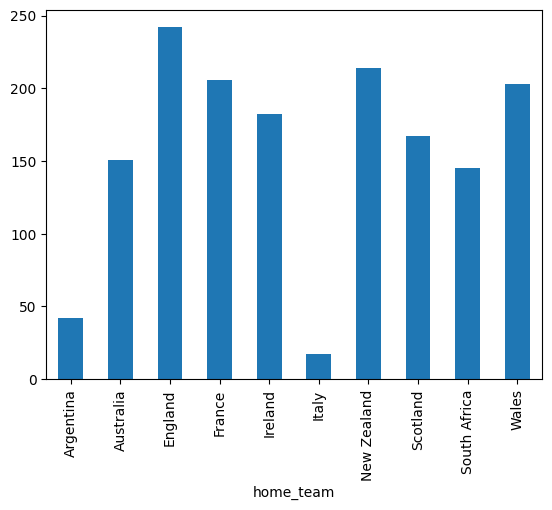

In [ ]:
#grafico de quantas vezes home_team teve retorno em result como Wineer

df[df.result == 'Winner'].groupby('home_team').size().plot(kind='bar')


## **Grafico de derrotas jogando fora**

<Axes: xlabel='home_team'>

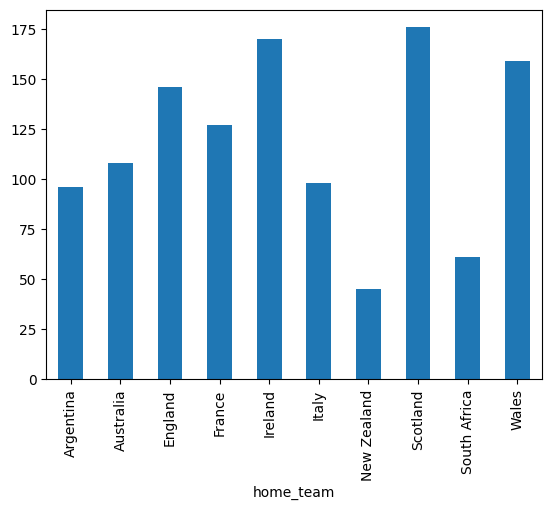

In [ ]:
df[df.result == 'Loser'].groupby('home_team').size().plot(kind='bar')

## **Grafico em linha para comparar as pontuações**

<Axes: xlabel='date'>

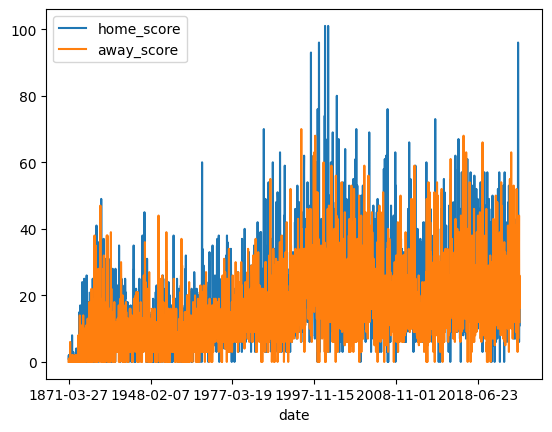

In [ ]:
#COMPARAÇÃO EM LINHA DOS PONTUÇÕES ENTRE JOGOS EM CASA E FORA

df.plot(x='date', y=['home_score', 'away_score'])

**Analisando esse grafico, fica evidente que os jogos em casa possuem certa vantagem de pontuação. Por outro lado, jogos fora de casa possuem um estabilidade maior.**

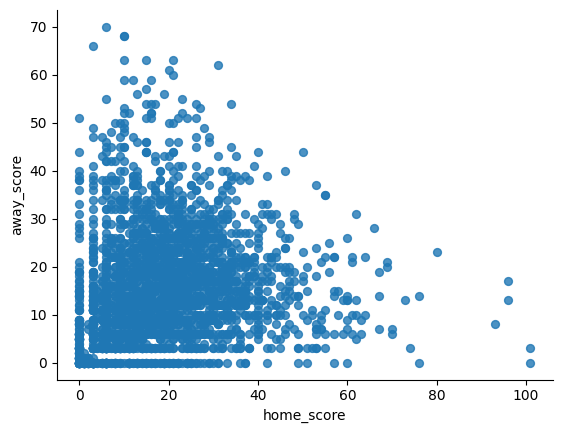

In [ ]:
#COMPARAÇÃO EM DISTRIBUIÇÃO DOS PONTUÇÕES ENTRE JOGOS EM CASA E FORA

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='home_score', y='away_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

**Com o grafico de disperção, podemos notar os agromerados, onde temos um em evidencia para as pontuações fora de casa**

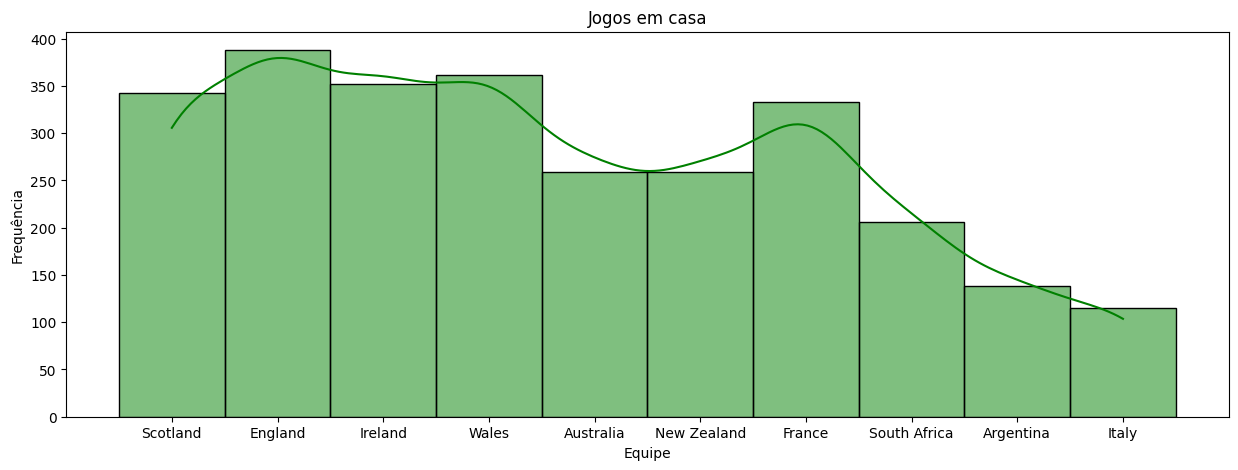

In [ ]:
# HISTOGRAMA DE JOGOS EM CASA de 1871 a 2023

plt.figure(figsize=(15, 5))
sns.histplot(data=df, x="home_team", color="green", kde=True)
plt.title("Jogos em casa")
plt.xlabel("Equipe")
plt.ylabel("Frequência")
plt.show()


**Com base nos dois histogramas, podemos notar que alguns paises tem mais jogos fora de casa do que outros como a França.**

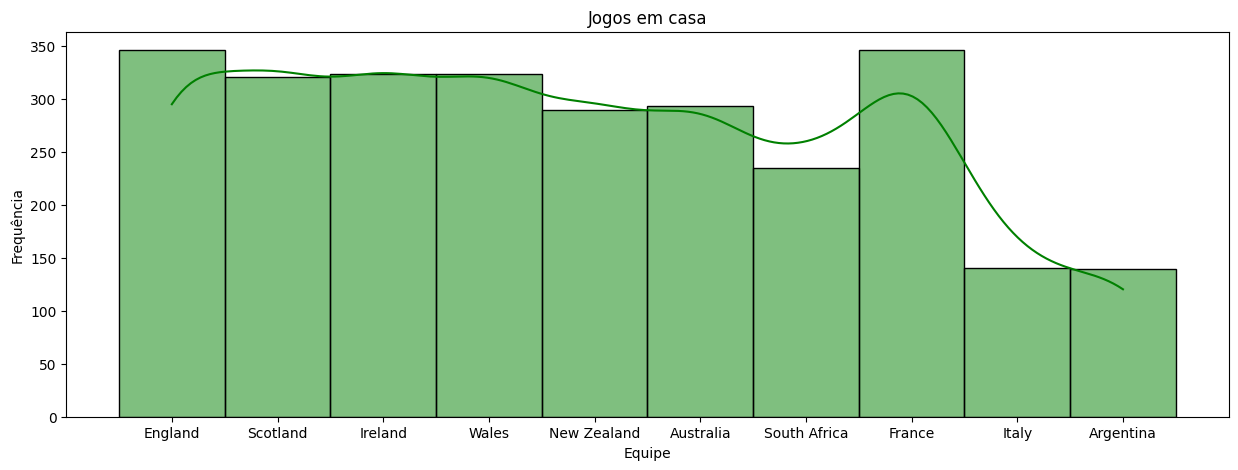

In [ ]:
# HISTOGRAMA DE JOGOS FORA DE CASA de 1871 a 2023

plt.figure(figsize=(15, 5))
sns.histplot(data=df, x="away_team", color="green", kde=True)
plt.title("Jogos em casa")
plt.xlabel("Equipe")
plt.ylabel("Frequência")
plt.show()


In [ ]:
#Grafico para comparar home_team e away_team com relação ao retorno Winner em results

import altair as alt
chart = alt.Chart(df).mark_bar().encode(
    x = alt.X('home_team:N', title='Home Team'),
    y = alt.Y('away_team:N', title='Away Team'),
    color = 'result:N',
).properties(
    width=900,
    height=500
)
chart


alt.Chart(...)

**Com este grafico comparativo, podemos notar uma predominancia da Italia com varias jogos ganhos fora de casa**

In [ ]:
#quantas vezes cada home_team teve o retorno Winner em result

df.groupby('home_team')['result'].value_counts().unstack()['Winner']

home_team
Argentina        42
Australia       151
England         242
France          206
Ireland         182
Italy            17
New Zealand     214
Scotland        167
South Africa    145
Wales           203
Name: Winner, dtype: int64

**Com essa lista, fica mais evidente a quantidade de vitorias em relação as partidas jogadas fora de casa**

##**Conclusão**

A análise dos dados de partidas de rugby das seleções nacionais entre 1871 e 2023 revelou padrões interessantes e significativos. Primeiramente, as vitórias fora de casa mostraram-se um indicador importante do nível de competitividade e resiliência das seleções, destacando aquelas capazes de superar adversidades e conquistar triunfos em ambientes hostis. Em segundo lugar, a quantidade de jogos disputados por cada seleção refletiu tanto o desenvolvimento histórico do rugby em diferentes regiões quanto a popularidade e a infraestrutura do esporte nesses locais.

Essa análise proporciona uma compreensão mais profunda da evolução do rugby ao longo dos anos e das características que definem as seleções mais bem-sucedidas. Além disso, ela oferece uma base para futuras investigações sobre fatores adicionais que possam influenciar o desempenho das seleções, como mudanças nas regras, profissionalização do esporte e avanços na preparação física e tática. Em última análise, ao revelar tendências e padrões históricos, este estudo contribui para uma apreciação mais rica e informada da trajetória do rugby no cenário internacional.
